This program is free software: you can redistribute it and/or modify
it under the terms of the GNU Lesser General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU Lesser General Public License for more details.

You should have received a copy of the GNU Lesser General Public License
along with this program.  If not, see <http://www.gnu.org/licenses/>.

___

- **Author:** Pau Manyer Fuertes
- **Email:** pau.manyer@bsc.es
- **Date:** June 2026
- **Institution:** Barcelona Supercomputing Center (BSC)
- **Department:** Computer Applications in Science and Engineering (CASE)
- **Research Group:** Nuclear Fusion  
___

This jupyter notebook file constitutes the testing script for solving using a CutFEM scheme the FREE-boundary plasma boundary problem with ITER tokamak geometry. In this case, the different external PF magnets are defined as COILS and central solenoids as MULTICOILS (see classes in Magnet.py). 

EQUILIPY solves using CutFEM the Grad-Shafranov nonlinear elliptic PDE modelling the equilibrium in an axisymmetrical plasma system. 

# DEFINE EQUILIBRIUM PROBLEM PARAMETERS

In [1]:
from _header import EQUILIPY_ROOT

from GradShafranovSolver import *

## CREATE GRAD-SHAFRANOV PROBLEM
Equilibrium = GradShafranovSolver()

## DECLARE SWITCHS:
##### GHOST PENALTY STABILISATION
Equilibrium.FIXED_BOUNDARY = False
Equilibrium.GhostStabilization = False
Equilibrium.PARALLEL = False

##### OUTPUT PLOTS IN RUNTIME
Equilibrium.plotelemsClas = False      # OUTPUT SWITCH FOR ELEMENTS CLASSIFICATION PLOTS AT EACH ITERATION
Equilibrium.plotPSI = True             # OUTPUT SWITCH FOR PSI SOLUTION PLOTS AT EACH ITERATION
##### OUTPUT FILES
Equilibrium.out_proparams = True       # OUTPUT SWITCH FOR SIMULATION PARAMETERS 
Equilibrium.out_boundaries = True
Equilibrium.out_elemsClas = True       # OUTPUT SWITCH FOR CLASSIFICATION OF MESH ELEMENTS
Equilibrium.out_plasmaLS = True        # OUTPUT SWITCH FOR PLASMA BOUNDARY LEVEL-SET FIELD VALUES
Equilibrium.out_plasmaBC = True        # OUTPUT SWITCH FOR PLASMA BOUNDARY CONDITION VALUES 
Equilibrium.out_plasmaapprox = True    # OUTPUT SWITCH FOR PLASMA BOUNDARY APPROXIMATION DATA 
Equilibrium.out_ghostfaces = True      # OUTPUT SWITCH FOR GHOST STABILISATION FACES DATA 
Equilibrium.out_quadratures = True
Equilibrium.out_elemsys = True         # OUTPUT SWITCH FOR ELEMENTAL MATRICES
##### OUTPUT PICKLING
Equilibrium.out_pickle = True          # OUTPUT SWITCH FOR SIMULATION DATA PYTHON PICKLE

# DEFINE NUMERICAL_TREATMENT PARAMETERS  
Equilibrium.dim = 2                    # PROBLEM SPATIAL DIMENSION
Equilibrium.QuadratureOrder2D = 8      # ORDER OF SURFACE NUMERICAL INTEGRATION QUADRATURES 
Equilibrium.QuadratureOrder1D = 5      # ORDER OF LENGTH NUMERICAL INTEGRATION QUADRATURES 
Equilibrium.ext_maxiter = 5            # EXTERNAL LOOP (PHI_B) MAXIMUM ITERATIONS
Equilibrium.ext_tol = 1.0e-3           # EXTERNAL LOOP (PHI_B) CONVERGENCE TOLERANCE
Equilibrium.int_maxiter = 10           # INTERNAL LOOP (PHI_NORM) MAXIMUM ITERATIONS
Equilibrium.int_tol = 1.0e-4           # INTERNAL LOOP (PHI_NORM) CONVERGENCE TOLERANCE
Equilibrium.tol_saddle = 0.1           # TOLERANCE FOR DISTANCE BETWEEN CONSECUTIVE ITERATION SADDLE POINTS (LETS PLASMA REGION CHANGE)
Equilibrium.beta = 1.0e6               # NITSCHE'S METHOD PENALTY PARAMETER
Equilibrium.Nconstrainedges = -1       # NUMBER OF PLAMA BOUNDARY APPROXIMATION EDGES ON WHICH CONSTRAIN BC
Equilibrium.zeta = 1.0e-2              # GHOST PENALTY PARAMETER
Equilibrium.R0_axis = 6.0              # MAGNETIC AXIS OPTIMIZATION ROUTINE INITIAL GUESS R COORDINATE
Equilibrium.Z0_axis = 1.0              # MAGNETIC AXIS OPTIMIZATION ROUTINE INITIAL GUESS Z COORDINATE
Equilibrium.R0_saddle = 5.0            # ACTIVE SADDLE POINT OPTIMIZATION ROUTINE INITIAL GUESS R COORDINATE
Equilibrium.Z0_saddle = -3.5           # ACTIVE SADDLE POINT OPTIMIZATION ROUTINE INITIAL GUESS Z COORDINATE
Equilibrium.opti_maxiter = 50          # CRITICAL POINTS OPTIMIZATION ALGORITHM MAXIMAL ITERATIONS NUMBER
Equilibrium.opti_tol = 1.0e-6          # CRITICAL POINTS OPTIMIZATION ALGORITHM SOLUTION TOLERANCE

Equilibrium.InitialiseParameters()
Equilibrium.InitialisePickleLists()

Equilipy --| Working directory: /home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY
Equilipy --| INITIALISE SIMULATION PARAMETERS...Done!


In [2]:
Equilibrium.InitialiseParameters()
Equilibrium.InitialisePickleLists()

Equilipy --| INITIALISE SIMULATION PARAMETERS...Done!


In [ ]:
###### LINEAR STRUCTURED TRIANGULAR ELEMENTS MESH
#MESH = 'TRI03_REC_STRUC_1.0'
#MESH = 'TRI03_REC_STRUC_0.5'
#MESH = 'TRI03_REC_STRUC_0.1'
#MESH = 'TRI03_REC_STRUC_0.05'
#MESH = 'TRI03_REC_STRUC_0.02'

###### QUADRATIC STRUCTURED TRIANGULAR ELEMENTS MESH
#MESH = 'TRI06_REC_STRUC_1.0'
#MESH = 'TRI06_REC_STRUC_0.5'
MESH = 'TRI06_REC_STRUC_0.1'
#MESH = 'TRI06_REC_STRUC_0.05'
#MESH = 'TRI06_REC_STRUC_0.02'

###### LINEAR UNSTRUCTURED TRIANGULAR ELEMENTS MESH
#MESH = 'TRI03_REC_UNSTR_1.0'
#MESH = 'TRI03_REC_UNSTR_0.5'
#MESH = 'TRI03_REC_UNSTR_0.1'
#MESH = 'TRI03_REC_UNSTR_0.05'
#MESH = 'TRI03_REC_UNSTR_0.02'

###### QUADRATIC UNSTRUCTURED TRIANGULAR ELEMENTS MESH
#MESH = 'TRI06_REC_UNSTR_1.0'
#MESH = 'TRI06_REC_UNSTR_0.5'
#MESH = 'TRI06_REC_UNSTR_0.1'
#MESH = 'TRI06_REC_UNSTR_0.05'
#MESH = 'TRI06_REC_UNSTR_0.02'

###### LINEAR STRUCTURED QUADRILATERAL ELEMENTS MESH
#MESH = 'QUA04_REC_1.0'
#MESH = 'QUA04_REC_0.5'
#MESH = 'QUA04_REC_0.1'
#MESH = 'QUA04_REC_0.05'
#MESH = 'QUA04_REC_0.02'

###### QUADRATIC STRUCTURED QUADRILATERAL ELEMENTS MESH
#MESH = 'QUA09_REC_1.0'
#MESH = 'QUA09_REC_0.5'
#MESH = 'QUA09_REC_0.1'
#MESH = 'QUA09_REC_0.05'
#MESH = 'QUA09_REC_0.02'

Equilibrium.MESH = Mesh(MESH)

Equilipy --| Mesh folder: /home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/MESHES/TRI06-SUPERFINE-REC
Equilipy --| READ MESH FILES...Done!


Equilipy --| Mesh folder: /home/pmanyerfuertes/Documents/BSC/EQUILI/EQUILIPY/EQUILIPY/MESHES/TRI03-FINE-ITFW
Equilipy --| READ MESH FILES...Done!


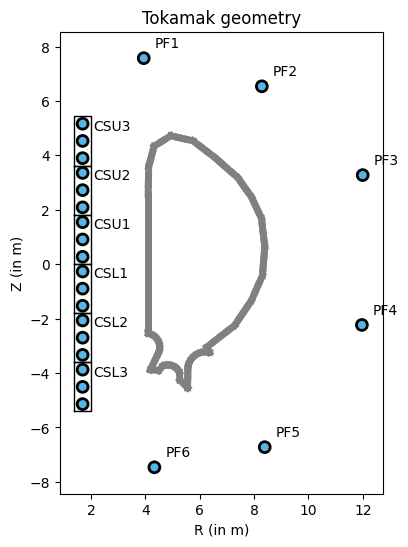

In [ ]:
##### DEFINE TOKAMAK EXTERNAL MAGNETS
# COILS
coil1 = Coil(name = 'PF1',
             X = np.array([3.9431,7.5741]),
             I = 5.73e6)
coil2 = Coil(name = 'PF2',
             X = np.array([8.2851,6.5398]),
             I = -2.88e6)
coil3 = Coil(name = 'PF3',
             X = np.array([11.9919,3.2752]),
             I = -5.81e6)
coil4 = Coil(name = 'PF4',
             X = np.array([11.9630,-2.2336]),
             I = -4.78e6)
coil5 = Coil(name = 'PF5',
             X = np.array([ 8.3908,-6.7269]),
             I = -7.81e6)
coil6 = Coil(name = 'PF6',
             X = np.array([4.3340, -7.4665]),
             I = 16.94e6)
   
# MULTICOIL SOLENOIDS
solewidth = 0.6
nr = 1
nz = 3
padr = 0.0
padz = 0.15
solenoid1 = RectangularMultiCoil(name = 'CSL3',
                                 Xe = np.array([[1.696-solewidth/2, -5.415],
                                                [1.696+solewidth/2, -5.415],
                                                [1.696+solewidth/2, -3.6067],
                                                [1.696-solewidth/2, -3.6067]]),
                                 nr = nr,
                                 nz = nz,
                                 padr = padr,
                                 padz = padz,
                                 I = 5.3e6)
solenoid2 = RectangularMultiCoil(name = 'CSL2',
                                 Xe = np.array([[1.696-solewidth/2, -3.606],
                                                [1.696+solewidth/2, -3.606],
                                                [1.696+solewidth/2, -1.7983],
                                                [1.696-solewidth/2, -1.7983]]),
                                 nr = nr,
                                 nz = nz,
                                 padr = padr,
                                 padz = padz,
                                 I = -10.3e6)
solenoid3 = RectangularMultiCoil(name = 'CSL1',
                                 Xe = np.array([[1.696-solewidth/2, -1.798],
                                                [1.696+solewidth/2, -1.798],
                                                [1.696+solewidth/2, 0.0],
                                                [1.696-solewidth/2, 0.0]]),
                                 nr = nr,
                                 nz = nz,
                                 padr = padr,
                                 padz = padz,
                                 I = -20.8e6)
solenoid4 = RectangularMultiCoil(name = 'CSU1',
                                 Xe = np.array([[1.696-solewidth/2, 0.0],
                                                [1.696+solewidth/2, 0.0],
                                                [1.696+solewidth/2, 1.8183],
                                                [1.696-solewidth/2, 1.8183]]),
                                 nr = nr,
                                 nz = nz,
                                 padr = padr,
                                 padz = padz,
                                 I = -20.8e6)
solenoid5 = RectangularMultiCoil(name = 'CSU2',
                                 Xe = np.array([[1.696-solewidth/2, 1.8183],
                                                [1.696+solewidth/2, 1.8183],
                                                [1.696+solewidth/2, 3.6267],
                                                [1.696-solewidth/2, 3.6267]]),
                                 nr = nr,
                                 nz = nz,
                                 padr = padr,
                                 padz = padz,
                                 I = -4.05e6)
solenoid6 = RectangularMultiCoil(name = 'CSU3',
                                 Xe = np.array([[1.696-solewidth/2, 3.6267],
                                                [1.696+solewidth/2, 3.6267],
                                                [1.696+solewidth/2, 5.435],
                                                [1.696-solewidth/2, 5.435]]),
                                 nr = nr,
                                 nz = nz,
                                 padr = padr,
                                 padz = padz,
                                 I = -4.82e6)

magnets = [coil1, coil2, coil3, coil4, coil5, coil6,
           solenoid1, solenoid2, solenoid3, solenoid4, solenoid5, solenoid6]

# TOKAMAK WALL MESH
TOKmesh = Mesh('TRI03_ITER_FIRSTWALL')
Equilibrium.TOKAMAK = Tokamak(WALL_MESH = TOKmesh,
                              MAGNETS = magnets)

Equilibrium.TOKAMAK.Plot()

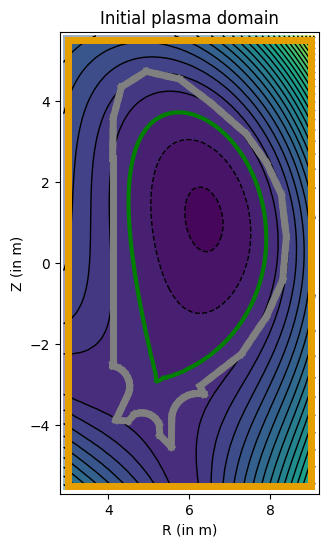

In [5]:
# DEFINE INITIAL PLASMA BOUNDARY
"""
# PLASMA BOUNDARY PARAMETRISED USING LINEAR SOLUTION 0-LEVEL CONTOUR
Equilibrium.initialPHI = InitialPlasmaBoundary(EQUILIBRIUM = Equilibrium,   
                                           GEOMETRY = 'LINEAR', # PREDEFINED MODEL
                                           R0 = 6.0,            # MEAN RADIUS          
                                           epsilon = 0.38,      # INVERSE ASPECT RATIO
                                           kappa = 1.8,         # ELONGATION
                                           delta = 0.34)        # TRIANGULARITY
"""

"""
# PLASMA BOUNDARY PARAMETRISED USING ZHENG SOLUTION 0-LEVEL CONTOUR
Equilibrium.initialPHI = InitialPlasmaBoundary(EQUILIBRIUM = Equilibrium,
                                           GEOMETRY = 'ZHENG', # PREDEFINED MODEL
                                           R0 = 6.0,           # MEAN RADIUS          
                                           epsilon = 0.32,     # INVERSE ASPECT RATIO
                                           kappa = 1.7,        # ELONGATION
                                           delta = 0.33)       # TRIANGULARITY
"""

import numpy as np

"""
X_SADDLE = np.array([5.5, -2.3])        # ACTIVE SADDLE POINT        
X_RIGHT = np.array([7.2, 0.6])          # POINT ON RIGHT
X_LEFT = np.array([4.8, 1.0])           # POINT ON LEFT
X_TOP = np.array([5.9, 2.8])            # POINT ON TOP
"""

"""
X_SADDLE = np.array([5.4, -2.9])
X_RIGHT = np.array([7.8, 0.4])
X_LEFT = np.array([4.5, 1.2])
X_TOP = np.array([5.9, 3.4])
"""

"""
X_SADDLE = np.array([5.3, -2.8])
X_RIGHT = np.array([7.9, 0.5])
X_LEFT = np.array([4.5, 1.2])
X_TOP = np.array([5.9, 3.7])
"""

X_SADDLE = np.array([5.2, -2.9])
X_RIGHT = np.array([7.9, 0.6])
X_LEFT = np.array([4.5, 1.5])
X_TOP = np.array([5.9, 3.7])


# PLASMA BOUNDARY PARAMETRISED cubicHam HAMILTONIAN 0-LEVEL CONTOUR
Equilibrium.initialPHI = InitialPlasmaBoundary(EQUILIBRIUM = Equilibrium,
                                           GEOMETRY = 'CUBICHAM',
                                           Xsaddle = X_SADDLE,  # ACTIVE SADDLE POINT        
                                           Xright = X_RIGHT,    # POINT ON RIGHT
                                           Xleft = X_LEFT,      # POINT ON LEFT
                                           Xtop = X_TOP)        # POINT ON TOP

"""
def PHI0(X):
    return
Equilibrium.initialPHI = InitialPlasmaBoundary(EQUILIBRIUM = Equilibrium,
                                           GEOMETRY = 'OTHER',
                                           PHI0 = PHI0)
"""

Equilibrium.initialPHI.Plot()

In [6]:
Equilibrium.DomainDiscretisation(INITIALISATION = True)

Equilipy --| PERFORM DOMAIN DISCRETISATION...
Equilipy --| INITIALISATION TASKS...
Equilipy --|      -> INITIALISE LEVEL-SET...Done!
Equilipy --|      -> INITIALISE ELEMENTS...
Equilipy --|          · MESH ELEMENTS MEAN AREA = 0.017818574514037656 m^2
Equilipy --|          · MESH ELEMENTS MEAN LENGTH = 0.20265348838508873 m
Equilipy --|      Done!
Equilipy --|      -> IDENTIFY ELEMENTS MESH RELATION...Done!
Equilipy --|      -> COMPUTE STANDARD NUMERICAL INTEGRATION QUADRATURES...Done!
Equilipy --| Done!
Equilipy --|      -> CLASSIFY ELEMENTS...Done!
Equilipy --|      -> APPROXIMATE PLASMA BOUNDARY INTERFACE...Done!
Equilipy --|      -> COMPUTE PLASMA BOUNDARY APPROXIMATION QUADRATURES...Equilipy --| Warning:  Element 2884, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 2884, subelem 1: surface integration quadrature is not accurate.
Done!
Equilipy --|      -> ASSIGN PLASMA BOUNDARY CONSTRAINT VALUES...Done!
Equilipy --| Done!


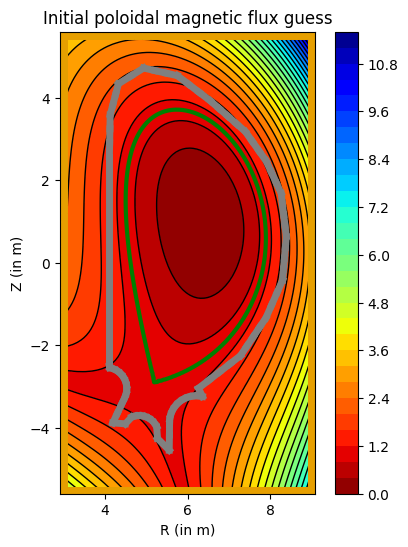

In [7]:
# DEFINE INITIAL GUESS FOR PLASMA MAGNETIC FLUX
"""
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'LINEAR', # PREDEFINED MODEL 
                                  R0 = 6.0,             # MEAN RADIUS          
                                  epsilon = 0.32,       # INVERSE ASPECT RATIO
                                  kappa = 1.7,          # ELONGATION
                                  delta = 0.33)         # TRIANGULARITY
"""                                  

"""
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'LINEAR', # PREDEFINED MODEL 
                                  R0 = 6.0,             # MEAN RADIUS          
                                  epsilon = 0.32,       # INVERSE ASPECT RATIO
                                  kappa = 1.7,          # ELONGATION
                                  delta = 0.33)         # TRIANGULARITY
"""                             
                                 
"""
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'ZHENG',  # PREDEFINED MODEL
                                  NOISE = True,         # WHITE NOISE 
                                  R0 = 6.0,             # MEAN RADIUS          
                                  epsilon = 0.32,       # INVERSE ASPECT RATIO
                                  kappa = 1.7,          # ELONGATION
                                  delta = 0.33,         # TRIANGULARITY
                                  A = 2.0)              # NOISE AMPLITUDE
"""

"""
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'NONLINEAR',  # PREDEFINED MODEL
                                  NOISE = True,             # WHITE NOISE 
                                  R0 = 6.0,                 # MEAN RADIUS
                                  A = 2.0)                  # NOISE AMPLITUDE         
"""   

"""
X_SADDLE = np.array([5.5, -2.3])        # ACTIVE SADDLE POINT        
X_RIGHT = np.array([7.2, 0.6])          # POINT ON RIGHT
X_LEFT = np.array([4.8, 1.0])           # POINT ON LEFT
X_TOP = np.array([5.9, 2.8])            # POINT ON TOP
"""

"""
X_SADDLE = np.array([5.4, -2.9])
X_RIGHT = np.array([7.8, 0.4])
X_LEFT = np.array([4.5, 1.2])
X_TOP = np.array([5.9, 3.4])
"""

"""
X_SADDLE = np.array([5.3, -2.8])
X_RIGHT = np.array([7.9, 0.5])
X_LEFT = np.array([4.5, 1.2])
X_TOP = np.array([5.9, 3.7])
"""

X_SADDLE = np.array([5.2, -2.9])
X_RIGHT = np.array([7.9, 0.6])
X_LEFT = np.array([4.5, 1.5])
X_TOP = np.array([5.9, 3.7])


X0 = list()
X0.append(np.array([6.0,0.0],dtype=float))
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'CUBICHAM',
                                  NORMALISE = True,
                                  Xsaddle = X_SADDLE,  # ACTIVE SADDLE POINT        
                                  Xright = X_RIGHT,    # POINT ON RIGHT
                                  Xleft = X_LEFT,      # POINT ON LEFT
                                  Xtop = X_TOP,        # POINT ON TOP
                                  X0 = X0)     

"""
def PSI0(X):
    return
Equilibrium.initialPSI = InitialGuess(EQUILIBRIUM = Equilibrium,
                                  PSI_GUESS = 'OTHER',
                                  PSI0 = PSI0)
"""

Equilibrium.initialPSI.Plot()

In [8]:
Equilibrium.InitialisePSI()

Equilipy --| INITIALISE PSI...
Equilipy --|      -> INITIALISE PSI ARRAYS...Done!
Equilipy --|      -> COMPUTE INITIAL GUESS FOR PSI_NORM...Done!
Equilipy --| Done!


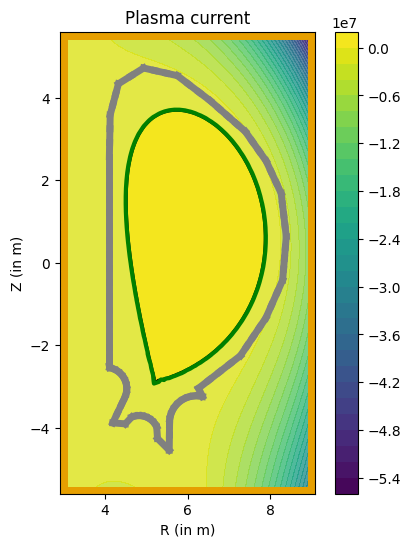

In [9]:
### DEFINE PLASMA CURRENT MODEL

# COMPUTE PRESSURE PROFILE FACTOR
R0 = 6.0        # MEAN RADIUS
kappa = 1.7     # ELONGATION
B0 = 9.0        # MAGNETIC FIELD MAGNITUDE ON MAGNETIC AXIS
q0 = 0.7        # TOKAMAK SAFETY FACTOR

P0=B0*((kappa**2)+1)/(Equilibrium.mu0*(R0**2)*q0*kappa)

"""
Equilibrium.PlasmaCurrent = CurrentModel(EQUILIBRIUM = Equilibrium,
                                     MODEL = 'JARDIN',
                                     P0 = P0,           # PLASMA PRESSURE ON MAGNETIC AXIS
                                     np = 2.0,          # 
                                     G0 = -34.4,        # TOROIDAL FUNCTION VALUE ON MAGNETIC AXIS
                                     ng = 2.0,          #
                                     Tcurrent = -15e6)  # TOTAL PLASMA CURRENT
"""

"""
Equilibrium.PlasmaCurrent = CurrentModel(EQUILIBRIUM = Equilibrium,
                                     MODEL = 'PCONSTRAIN',
                                     P0 = P0,           # PLASMA PRESSURE ON MAGNETIC AXIS
                                     alpha_m = 1,       # 
                                     alpha_n = 2,       #
                                     Tcurrent = 15e6)  # TOTAL PLASMA CURRENT
"""

Equilibrium.PlasmaCurrent = CurrentModel(EQUILIBRIUM = Equilibrium,
                                     MODEL = 'APEC',
                                     Ii = 0.81,         # PLASMA INTERNAL INDUCTANCE
                                     Betap = 0.75,      # POLOIDAL BETA
                                     R0 = 6.0,          # MEAN RADIUS
                                     Tcurrent = 15e6)   # TOTAL PLASMA CURRENT


"""
# USER DEFINED MODEL
def Jphi(X,PSI):
    return 6*X[0]
Equilibrium.PlasmaCurrent = CurrentModel(EQUILIBRIUM = Equilibrium,
                                     MODEL = 'OTHER',
                                     Jphi = Jphi,
                                     PSI_INDEPENDENT = False)
"""

Equilibrium.IntegratePlasmaDomain(Equilibrium.PlasmaCurrent.Jphi)

Equilibrium.PlasmaCurrent.Plot()

Equilipy --| PREPARE OUTPUT DIRECTORY...Done!
Equilipy --| INITIALISE PSI_B...
Equilipy --|      -> COMPUTE INITIAL COMPUTATIONAL DOMAIN BOUNDARY VALUES PSI_B...Done!
Equilipy --|      -> ASSIGN INITIAL COMPUTATIONAL DOMAIN BOUNDARY VALUES...Done!
Equilipy --| Done!
Equilipy --| WRITE INITIAL SIMULATION DATA...Done!


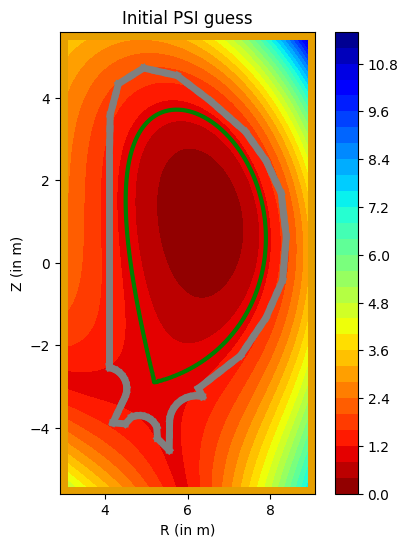

Equilipy --| START ITERATION...
Equilipy --| OUTER ITERATION = 1 , INNER ITERATION = 1
Equilipy --|      Total current =  14999999.999999948
Equilipy --|      Integrate non-cut elements contributions...Done!
Equilipy --|      Integrate cut-elements subelements contributions...Done!
Equilipy --|      Integrate cut-elements interface contributions...Done!
Equilipy --| Done!
Equilipy --| LOCAL EXTREMUM AT  [6.45471572 0.81662658]  (ELEMENT  876 ) WITH VALUE PSI_0 =  -11.702119643822675
Equilipy --| SADDLE POINT AT  [ 5.08685544 -3.29527033]  (ELEMENT  2368 ) WITH VALUE PSI_X =  -0.3844392339921334


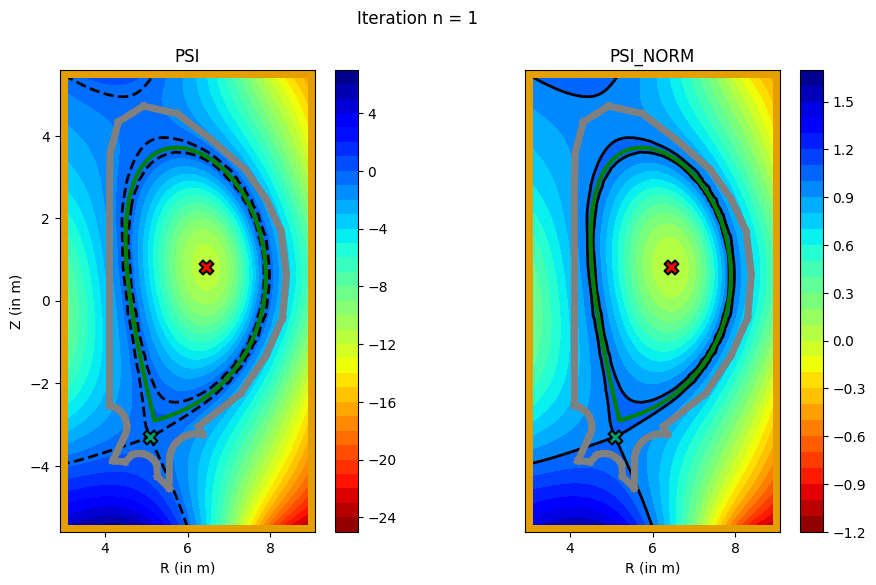

Equilipy --| Internal iteration =  1 , PSI_NORM residu =  2.9282036018554822
Equilipy --|  
Equilipy --| PERFORM DOMAIN DISCRETISATION...
Equilipy --|      -> CLASSIFY ELEMENTS...Done!
Equilipy --|      -> APPROXIMATE PLASMA BOUNDARY INTERFACE...Done!
Equilipy --|      -> COMPUTE PLASMA BOUNDARY APPROXIMATION QUADRATURES...Equilipy --| Warning:  Element 387, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 387, subelem 1: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 446, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 446, subelem 1: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 679, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 679, subelem 1: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 797, subelem 0: surface integration quadrature is not accurate.
Equilipy -

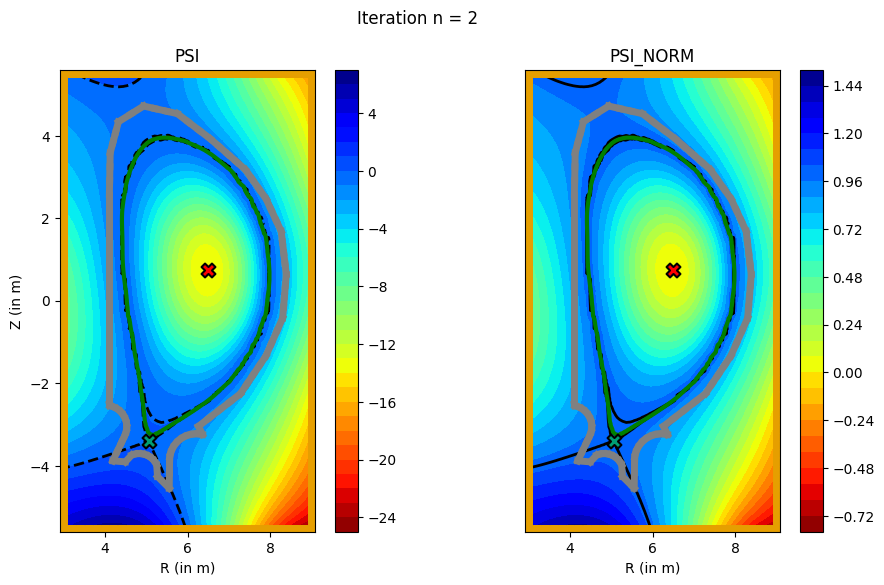

Equilipy --| Internal iteration =  2 , PSI_NORM residu =  0.12089419964404803
Equilipy --|  
Equilipy --| PERFORM DOMAIN DISCRETISATION...
Equilipy --|      -> CLASSIFY ELEMENTS...Done!
Equilipy --|      -> APPROXIMATE PLASMA BOUNDARY INTERFACE...Done!
Equilipy --|      -> COMPUTE PLASMA BOUNDARY APPROXIMATION QUADRATURES...Equilipy --| Warning:  Element 1316, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 1316, subelem 1: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 2047, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 2047, subelem 1: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 2188, subelem 0: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 2188, subelem 1: surface integration quadrature is not accurate.
Equilipy --| Warning:  Element 2356, subelem 0: surface integration quadrature is not accurate.
Eq

IndexError: list index out of range

In [10]:
## NAME SIMULATION CASE 
CASE = "TS-FREE-APEC-ITER-MULTICOILS"

## COMPUTE PLASMA EQUILIBRIUM
Equilibrium.EQUILIPY(CASE)

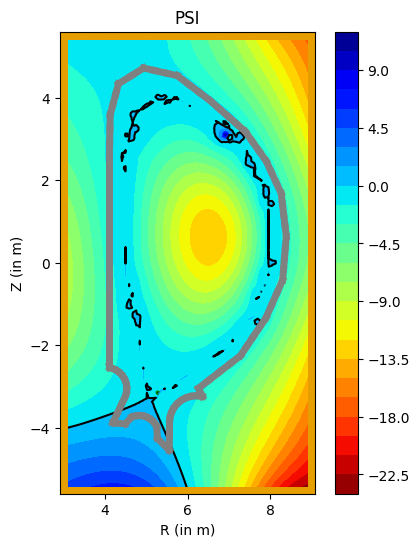

In [ ]:
Equilibrium.PlotPSI()